In [43]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cropEyeRegion import getCroppedEyeRegion

%matplotlib inline

In [44]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0,10.0)
matplotlib.rcParams['image.cmap'] = 'gray'

In [45]:
predictions2Label = {0: "No Glasses", 1: "With Glasses"}

In [46]:
# Path 1 is class 0 and path 2 is class 1
path1 = 'data/images/glassesDataset/cropped_withoutGlasses2'
path2 = 'data/images/glassesDataset/cropped_withGlasses2'

In [47]:
def getTrainTest(path, class_val, test_fraction=0.2):
    trainData = []
    testData = []
    trainLabels = []
    testLabels = []
    inputDir = os.path.expanduser(path)

    if os.path.isdir(inputDir):
        images = os.listdir(inputDir)
        images.sort()
        nTest = int(len(images) * test_fraction)

    for counter, img in enumerate(images):
        im = cv2.imread(os.path.join(inputDir, img))

        if counter < nTest:
            testData.append(im)
            testLabels.append(class_val)
        else:
            trainData.append(im)
            trainLabels.append(class_val)

    return trainData, trainLabels, testData, testLabels

In [48]:
def svmInit(C, gamma):
    model = cv2.ml.SVM_create()
    model.setGamma(gamma)
    model.setC(C)
    model.setKernel(cv2.ml.SVM_RBF)
    model.setType(cv2.ml.SVM_C_SVC)

    return model

In [49]:
def svmTrain(model, samples, responses):
    model.train(samples, cv2.ml.ROW_SAMPLE, responses)
    return model

In [50]:
def svmPredict(model, samples):
    return model.predict(samples)[1].ravel()

In [51]:
def svmEvaluate(model, samples, labels):
    predictions = svmPredict(model, samples)
    accuracy = (labels == predictions).mean()
    print('Percentage Accuracy: %.2f %%' % (accuracy*100))
    return accuracy

In [52]:
def prepareData(data):
    featureVectorLength = len(data[0])
    features = np.float32(data).reshape(-1, featureVectorLength)
    return features

In [53]:
def computeHOG(hog, data):
    hogData = []
    for image in data:
        hogFeatures = hog.compute(image)
        hogData.append(hogFeatures)

    return hogData

In [54]:
# Initialize hog params
winSize = (96, 32)
blockSize = (8, 8)
blockStride = (8, 8)
cellSize = (4, 4)
nbins = 9
derivAperture = 0
winSigma = 4.0
histogramNormType = 1
L2HysThreshold = 2.0000000000000001e-01
gammaCorrection = 1
nlevels = 64

hog = cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, 
                      nbins,derivAperture, winSigma, 
                      histogramNormType,L2HysThreshold, 
                      gammaCorrection, nlevels, 1)

In [55]:
# Get training and testing images for both classes
negTrainImages, negTrainLabels, negTestImages, negTestLabels = \
getTrainTest(path1, 0, .2)
posTrainImages, posTrainLabels, posTestImages, posTestLabels = \
getTrainTest(path2, 1, .2)

# Append Positive and Negative Images for Train and Test
trainImages = np.concatenate((np.array(negTrainImages), 
                        np.array(posTrainImages)), 
                            axis=0)
testImages = np.concatenate((np.array(negTestImages), 
                          np.array(posTestImages)), 
                          axis=0)

# Append Positive and Negative Labels for Train and Test
trainLabels = np.concatenate((np.array(negTrainLabels), 
                          np.array(posTrainLabels)), 
                          axis=0)
testLabels = np.concatenate((np.array(negTestLabels), 
                          np.array(posTestLabels)), 
                          axis=0)

In [56]:
### Feature computation for the training and testing data  ##
trainHOG = computeHOG(hog, trainImages)
testHOG = computeHOG(hog, testImages)

# Convert hog data into features recognized by SVM model
trainFeatures = prepareData(trainHOG)
testFeatures = prepareData(testHOG)

In [57]:
###########  SVM Training  ##############
model = svmInit(C=2.5, gamma=0.02)  # C = 0.1, gamma 10 for 
#linear kernel
model = svmTrain(model, trainFeatures, trainLabels)
model.save("eyeGlassClassifierModel.yml")

In [58]:
##########  SVM Testing  ###############
# We will load the model again and test the model
# This is just to explain how to load an SVM model
# You can use the model directly
savedModel = cv2.ml.SVM_load("eyeGlassClassifierModel.yml")

# Find accuracy of the test data by evaluating the model on 
# the test data
accuracy = svmEvaluate(savedModel, testFeatures, testLabels)

Percentage Accuracy: 92.45 %


In [ ]:
# Perform for a separate test image
filename = "data/images/glassesDataset/glasses_4.jpg"
testImage = cv2.imread(filename)
cropped = getCroppedEyeRegion(testImage)
testHOG = computeHOG(hog, np.array([cropped]))
testFeatures = prepareData(testHOG)
predictions = svmPredict(savedModel, testFeatures)
print("Prediction = {}"
      .format(predictions2Label[int(predictions[0])]))

Eye Height between : 49,148
Prediction = With Glasses


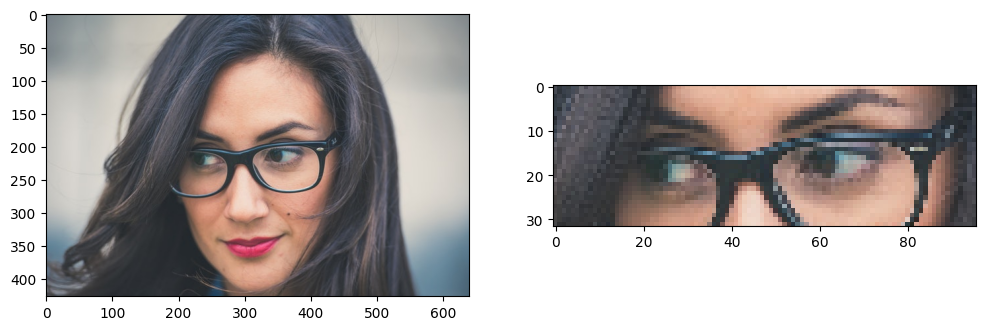

In [61]:
plt.figure(figsize=(12,12))
plt.subplot(1,2,1)
plt.imshow(testImage[:,:,::-1])
plt.subplot(1,2,2)
plt.imshow(cropped[:,:,::-1])
plt.show()

In [62]:
# Perform for a separate test image
filename = "data/images/glassesDataset/no_glasses1.jpg"
testImage = cv2.imread(filename)
cropped = getCroppedEyeRegion(testImage)
testHOG = computeHOG(hog, np.array([cropped]))
testFeatures = prepareData(testHOG)
predictions = svmPredict(savedModel, testFeatures)
print("Prediction = {}"
      .format(predictions2Label[int(predictions[0])]))

Eye Height between : 26,79
Prediction = No Glasses


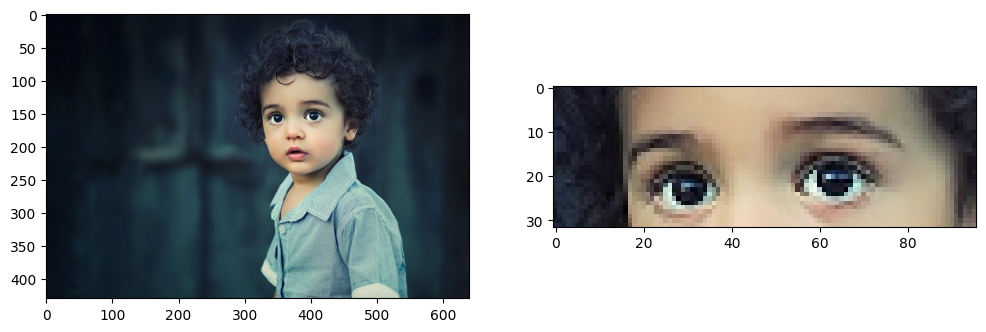

In [63]:
plt.figure(figsize=(12,12))
plt.subplot(1,2,1)
plt.imshow(testImage[:,:,::-1])
plt.subplot(1,2,2)
plt.imshow(cropped[:,:,::-1])
plt.show()

#### Pedestrian Detection using HOG & SVM in OpenCV

In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0,10.0)
matplotlib.rcParams['image.cmap'] = 'gray'

In [3]:
# returns image paths in given folder
# with extensions as defined in imgExts
def getImagePaths(folder, imgExts):
  imagePaths = []
  for x in os.listdir(folder):
    xPath = os.path.join(folder, x)
    if os.path.splitext(xPath)[1] in imgExts:
      imagePaths.append(xPath)
  return imagePaths


# read images in a folder
# return list of images and labels
def getDataset(folder, classLabel):
  images = []
  labels = []
  imagePaths = getImagePaths(folder, ['.jpg', '.png', '.jpeg'])
  for imagePath in imagePaths:
    # print(imagePath)
    im = cv2.imread(imagePath, cv2.IMREAD_COLOR)
    images.append(im)
    labels.append(classLabel)
  return images, labels

In [4]:
# Initialize SVM with parameters
def svmInit(C, gamma):
  model = cv2.ml.SVM_create()
  model.setGamma(gamma)
  model.setC(C)
  model.setKernel(cv2.ml.SVM_LINEAR)
  model.setType(cv2.ml.SVM_C_SVC)
  model.setTermCriteria((cv2.TERM_CRITERIA_EPS + 
                         cv2.TERM_CRITERIA_MAX_ITER, 
                         1000, 1e-3))
  return model


# Train SVM on data and labels
def svmTrain(model, samples, labels):
  model.train(samples, cv2.ml.ROW_SAMPLE, labels)


# predict labels for given samples
def svmPredict(model, samples):
  return model.predict(samples)[1]


# evaluate a model by comparing
# predicted labels and ground truth
def svmEvaluate(model, samples, labels):
  labels = labels[:, np.newaxis]
  pred = model.predict(samples)[1]
  correct = np.sum((labels == pred))
  err = (labels != pred).mean()
  print('label -- 1:{}, -1:{}'.format(np.sum(pred == 1), 
          np.sum(pred == -1)))
  return correct, err * 100


# create a directory if it doesn't exist
def createDir(folder):
  try:
    os.makedirs(folder)
  except OSError:
    print('{}: already exists'.format(folder))
  except Exception as e:
    print(e)

In [5]:
# compute HOG features for given images
def computeHOG(hog, images):
  hogFeatures = []
  for image in images:
    hogFeature = hog.compute(image)
    hogFeatures.append(hogFeature)
  return hogFeatures


# Convert HOG descriptors to format recognized by SVM
def prepareData(hogFeatures):
  featureVectorLength = len(hogFeatures[0])
  data = np.float32(hogFeatures).reshape(-1, featureVectorLength)
  return data

In [6]:
# Initialize HOG parameters
winSize = (64, 128)
blockSize = (16, 16)
blockStride = (8, 8)
cellSize = (8, 8)
nbins = 9
derivAperture = 1
winSigma = -1
histogramNormType = 0
L2HysThreshold = 0.2
gammaCorrection = True
nlevels = 64
signedGradient = False

# Initialize HOG
hog = cv2.HOGDescriptor(winSize, blockSize, blockStride,
                      cellSize, nbins,derivAperture,
                      winSigma, histogramNormType, L2HysThreshold, 
                      gammaCorrection, nlevels,signedGradient)

In [7]:
# Flags to turn on/off training or testing
trainModel = True
testModel = True
queryModel = True

In [8]:
rootDir = 'data/images/INRIAPerson/'

trainDir = os.path.join(rootDir, 'train_64x128_H96')
testDir = os.path.join(rootDir, 'test_64x128_H96')

In [9]:
if trainModel:
    # Read iamges from pos and neg directories
    trainPosDir = os.path.join(trainDir, 'posPatches')
    trainNegDir = os.path.join(trainDir, 'negPatches')

    trainPosImages, trainPosLabels = getDataset(trainPosDir, 1)
    trainNegImages, trainNegLabels = getDataset(trainNegDir, -1)

    print(set([x.shape for x in trainPosImages]))
    print(set([x.shape for x in trainNegImages]))

    print('Positive = {}, {} || negative = {}, {}'.format(len(trainPosImages), len(trainPosLabels), len(trainNegImages), len(trainNegLabels)))

    trainImages = np.concatenate((np.array(trainPosImages), np.array(trainNegImages)), axis=0)
    trainLabels = np.concatenate((np.array(trainPosLabels), np.array(trainNegLabels)), axis=0)

    hogTrain = computeHOG(hog, trainImages)

    trainData = prepareData(hogTrain)

    print('trainData: {}, trainLabels: {}'.format(trainData.shape, trainLabels.shape))

    model = svmInit(C=0.01, gamma = 0)
    svmTrain(model, trainData, trainLabels)
    model.save('data/models/svmINRIAPerson.yml') # similar to pedestrian.yml file

{(128, 64, 3)}
{(128, 64, 3)}
Positive = 2416, 2416 || negative = 12180, 12180
trainData: (14596, 3780), trainLabels: (14596,)


In [10]:
if testModel:
    model = cv2.ml.SVM_load('data/models/svmINRIAPerson.yml')

    testPosDir = os.path.join(testDir, 'posPatches')
    testNegDir = os.path.join(testDir, 'negPatches')

    testPosImages, testPosLabels = getDataset(testPosDir, 1)
    testNegImages, testNegLabels = getDataset(testNegDir, -1)

    hogPosTest = computeHOG(hog, testPosImages)
    testPosData = prepareData(hogPosTest)

    posCurrent, posError = svmEvaluate(model, testPosData, np.array(testPosLabels))

    tp = posCurrent
    fp = len(testPosLabels) - posCurrent
    print(f'TP: {tp}, FP: {fp}, Total: {len(testPosLabels)}, error: {posError}')

    hogNegTest = computeHOG(hog, testNegImages)
    testNegData = prepareData(hogNegTest)

    negCurrent, negError = svmEvaluate(model, testNegData, np.array(testNegLabels))

    tn = negCurrent
    fn = len(testNegLabels) - negCurrent
    print(f'TN: {tn}, FN: {fn}, Total: {len(testNegLabels)}, error: {negError}')

    precision = tp * 100 / (tp + fp)
    recall = tp * 100 / (tp + fn)

    print(f'Precision: {precision}, Recall: {recall}')

label -- 1:1064, -1:62
TP: 1064, FP: 62, Total: 1126, error: 5.506216696269982
label -- 1:18, -1:4512
TN: 4512, FN: 18, Total: 4530, error: 0.3973509933774834
Precision: 94.49378330373001, Recall: 98.33641404805915


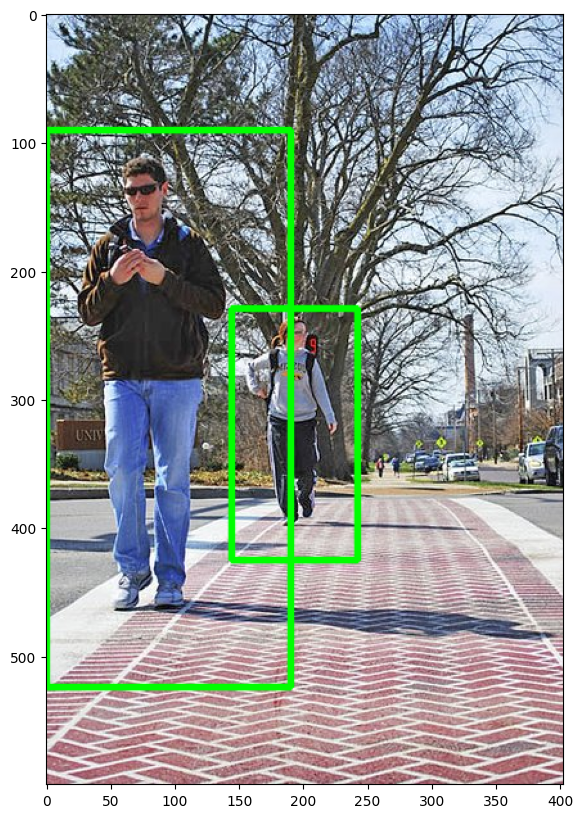

In [ ]:
if queryModel:
    model = cv2.ml.SVM_load('data/models/svmINRIAPerson.yml')

    sv = model.getSupportVectors()
    rho, alpha, svidx = model.getDecisionFunction(0)
    svmDetector = np.zeros(sv.shape[1]+1, dtype = sv.dtype)
    svmDetector[:-1] = -sv[:]
    svmDetector[-1] = rho

    hog.setSVMDetector(svmDetector)

    filename = 'data/images/pedestrians/3.jpg'
    queryImage = cv2.imread(filename, cv2.IMREAD_COLOR)

    # finalThreshold = 2 is in the course material, but it's throwing errors when I try it here
    # bboxes, weights = hog.detectMultiScale(queryImage, winStride=(8,8), padding=(32,32), scale=1.05, finalThreshold = 2, hitThreshold=1.0)
    bboxes, weights = hog.detectMultiScale(queryImage, winStride=(8,8), padding=(32,32), scale=1.05, hitThreshold=1.0)

    for bbox in bboxes:
        x1, y1, w, h = bbox
        x2, y2 = x1 + w, y1 + h
        cv2.rectangle(queryImage, (x1, y1), (x2, y2), (0, 255, 0), thickness=3, lineType=cv2.LINE_AA)

    plt.imshow(queryImage[:,:,::-1])

Comparison of our trained model with OpenCV's Pedestrian Detector

In [15]:
# Initialize HOG
# Initialize HOG parameters
winSize = (64, 128)
blockSize = (16, 16)
blockStride = (8, 8)
cellSize = (8, 8)
nbins = 9
derivAperture = 1
winSigma = -1
histogramNormType = 0
L2HysThreshold = 0.2
gammaCorrection = True
nlevels = 64
signedGradient = False

# Initialize HOG
hog = cv2.HOGDescriptor(winSize, blockSize, blockStride,
                        cellSize, nbins, derivAperture,
                        winSigma, histogramNormType, L2HysThreshold,
                        gammaCorrection, nlevels, signedGradient)

In [17]:
# Load model trained by us
model = cv2.ml.SVM_load('data/models/svmINRIAPerson.yml')
sv = model.getSupportVectors()
rho, aplha, svidx = model.getDecisionFunction(0)
svmDetectorTrained = np.zeros(sv.shape[1] + 1, dtype=sv.dtype)
svmDetectorTrained[:-1] = -sv[:]
svmDetectorTrained[-1] = rho
# set SVMDetector trained by us in HOG
hog.setSVMDetector(svmDetectorTrained)

In [18]:
# OpenCV's HOG based Pedestrian Detector
hogDefault = cv2.HOGDescriptor(winSize, blockSize, blockStride,
                               cellSize, nbins, derivAperture,
                               winSigma, histogramNormType, 
                               L2HysThreshold,gammaCorrection,
                               nlevels, signedGradient)
svmDetectorDefault = cv2.HOGDescriptor_getDefaultPeopleDetector()
hogDefault.setSVMDetector(svmDetectorDefault)

processing: data/images/pedestrians\1.jpg
Trained Detector :: pedestrians detected: 4
Default Detector :: pedestrians detected: 6


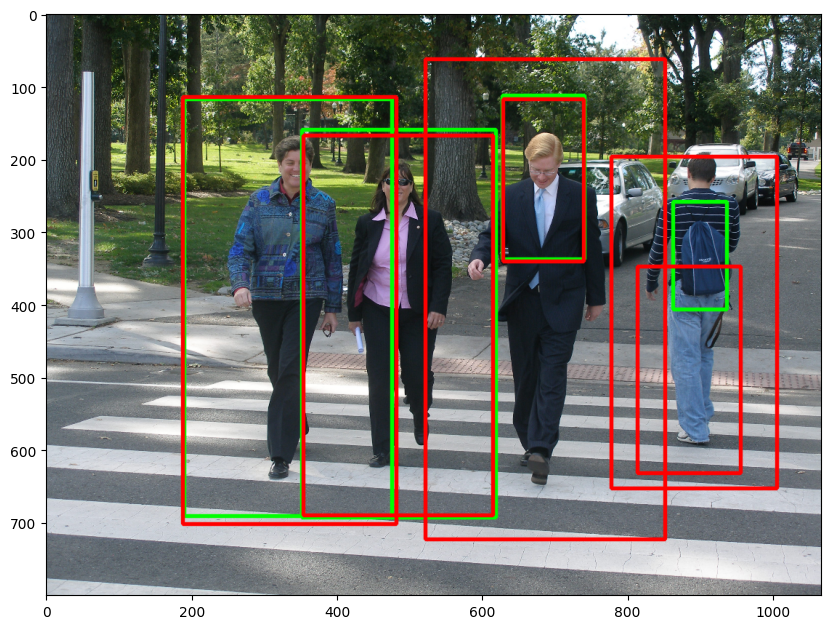

processing: data/images/pedestrians\2.jpg
Trained Detector :: pedestrians detected: 3
Default Detector :: pedestrians detected: 3


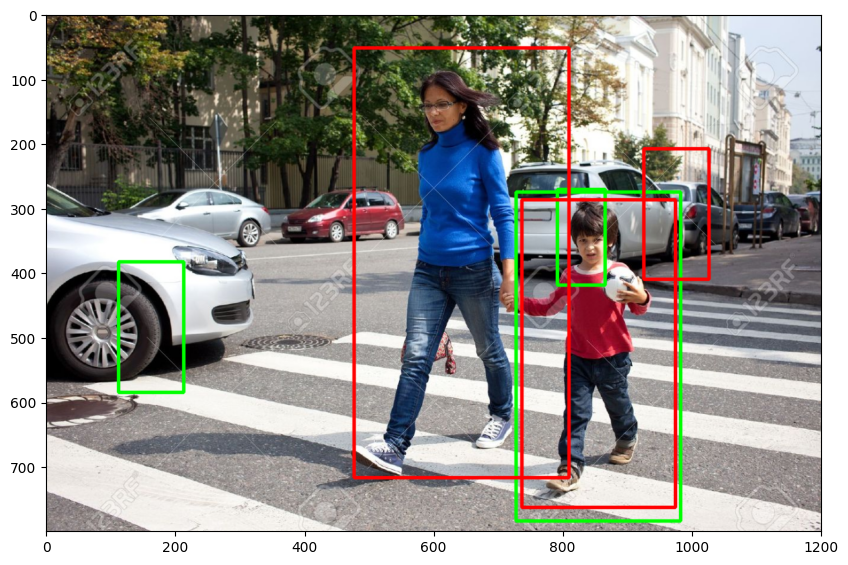

processing: data/images/pedestrians\3.jpg
Trained Detector :: pedestrians detected: 2
Default Detector :: pedestrians detected: 2


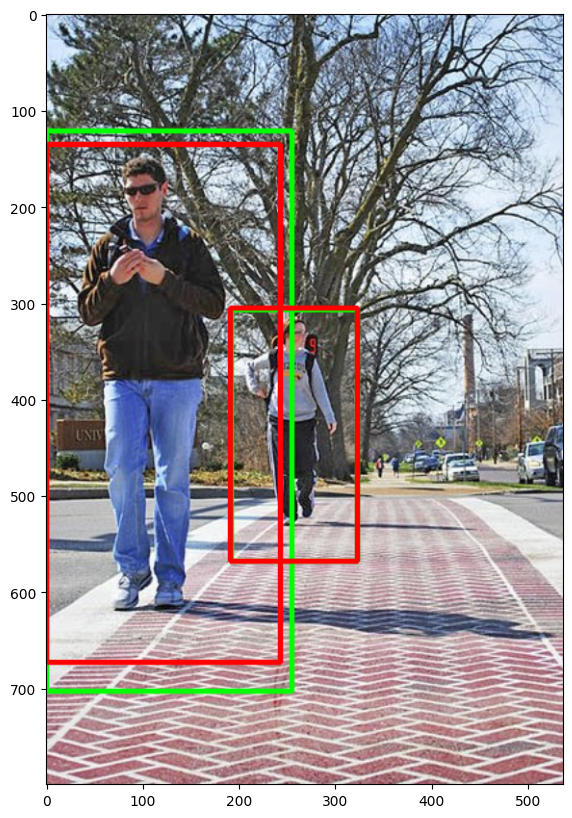

processing: data/images/pedestrians\4.jpg
Trained Detector :: pedestrians detected: 2
Default Detector :: pedestrians detected: 3


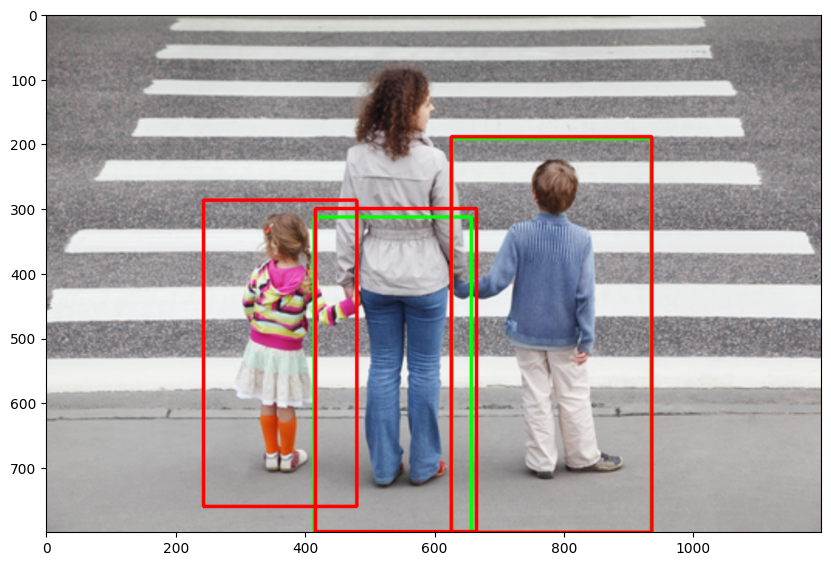

processing: data/images/pedestrians\5.jpg
Trained Detector :: pedestrians detected: 4
Default Detector :: pedestrians detected: 4


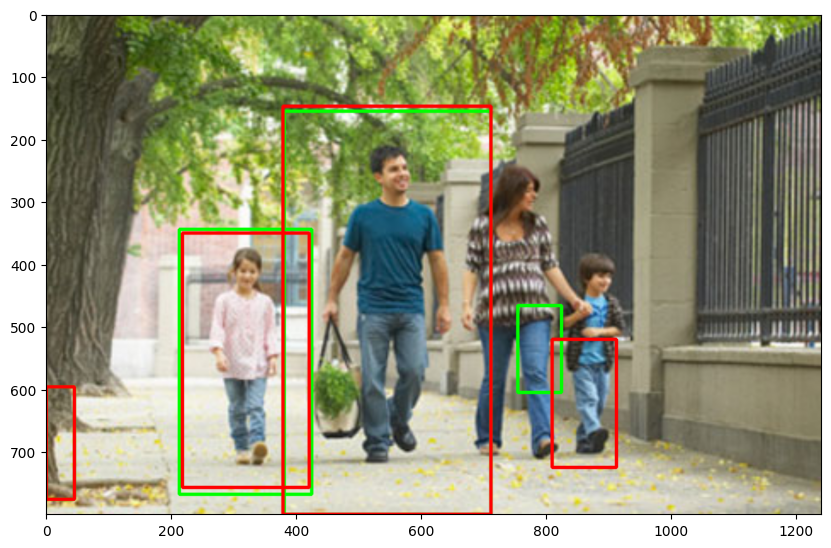

processing: data/images/pedestrians\race.jpg
Trained Detector :: pedestrians detected: 9
Default Detector :: pedestrians detected: 10


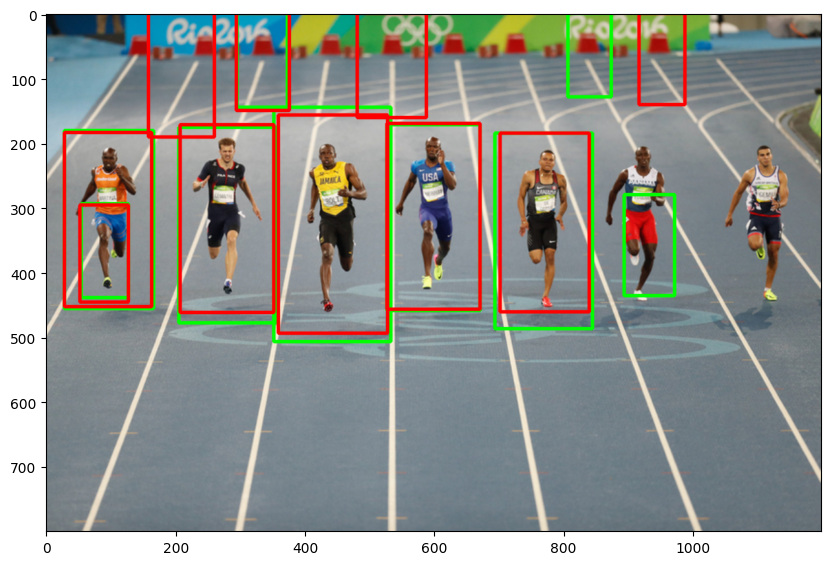

In [21]:
# read images from pedestrians directory
imageDir = 'data/images/pedestrians'
imagePaths = glob.glob(os.path.join(imageDir, '*.jpg'))

# We will run pedestrian detector at an fixed height image
finalHeight = 800.0

for imagePath in imagePaths:
    print('processing: {}'.format(imagePath))

    # read image
    im = cv2.imread(imagePath, cv2.IMREAD_COLOR)

    # resize image to height finalHeight
    scale = finalHeight / im.shape[0]
    im = cv2.resize(im, None, fx=scale, fy=scale)
    
    # Detect people using trained and default SVM detectors
    # detectMultiScale using detector trained by us
    bboxes, weights = hog.detectMultiScale(im, winStride=(8, 8), \
                                    padding=(32, 32),scale=1.05, \
                                    hitThreshold=1.0)

    # detectMultiScale using default detector
    bboxes2, weights2 = hogDefault.detectMultiScale(im, winStride=(8, 8), \
                                padding=(32, 32),scale=1.05, \
                                hitThreshold=0)
    
    # Draw found rectangles on image. We will draw 
    # green boxes for people detected by trained model and 
    # red boxes for people detected by OpenCV’s default model.
    # print pedestrians detected
    if len(bboxes) > 0:
        print('Trained Detector :: pedestrians detected: {}'
                .format(bboxes.shape[0]))
    if len(bboxes2) > 0:
        print('Default Detector :: pedestrians detected: {}'
                .format(bboxes2.shape[0]))

    # Draw detected bouunding boxes over image
    # Red = default detector, Green = Trained Detector
    for bbox in bboxes:
        x1, y1, w, h = bbox
        x2, y2 = x1 + w, y1 + h
        cv2.rectangle(im, (x1, y1), (x2, y2), 
                      (0, 255, 0), thickness=3, 
                      lineType=cv2.LINE_AA)

    for bbox in bboxes2:
        x1, y1, w, h = bbox
        x2, y2 = x1 + w, y1 + h
        cv2.rectangle(im, (x1, y1), (x2, y2), 
                      (0, 0, 255), thickness=3, 
                      lineType=cv2.LINE_AA)
    # Finally show the result and also write it to disk.
    # Show final result
    plt.imshow(im[:,:,::-1])
    # Write image to disk
    imResultPath = os.path.join('results', os.path.basename(imagePath))
    cv2.imwrite(imResultPath, im)
    plt.show()

#### Face detection using HAAR cascades

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
face_cascade = cv2.CascadeClassifier('data/models/haarcascade_frontalface_default.xml')
faceNeighborsMax = 10
neighborStep = 1

In [3]:
frame = cv2.imread("data/images/hillary_clinton.jpg")
frameGray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

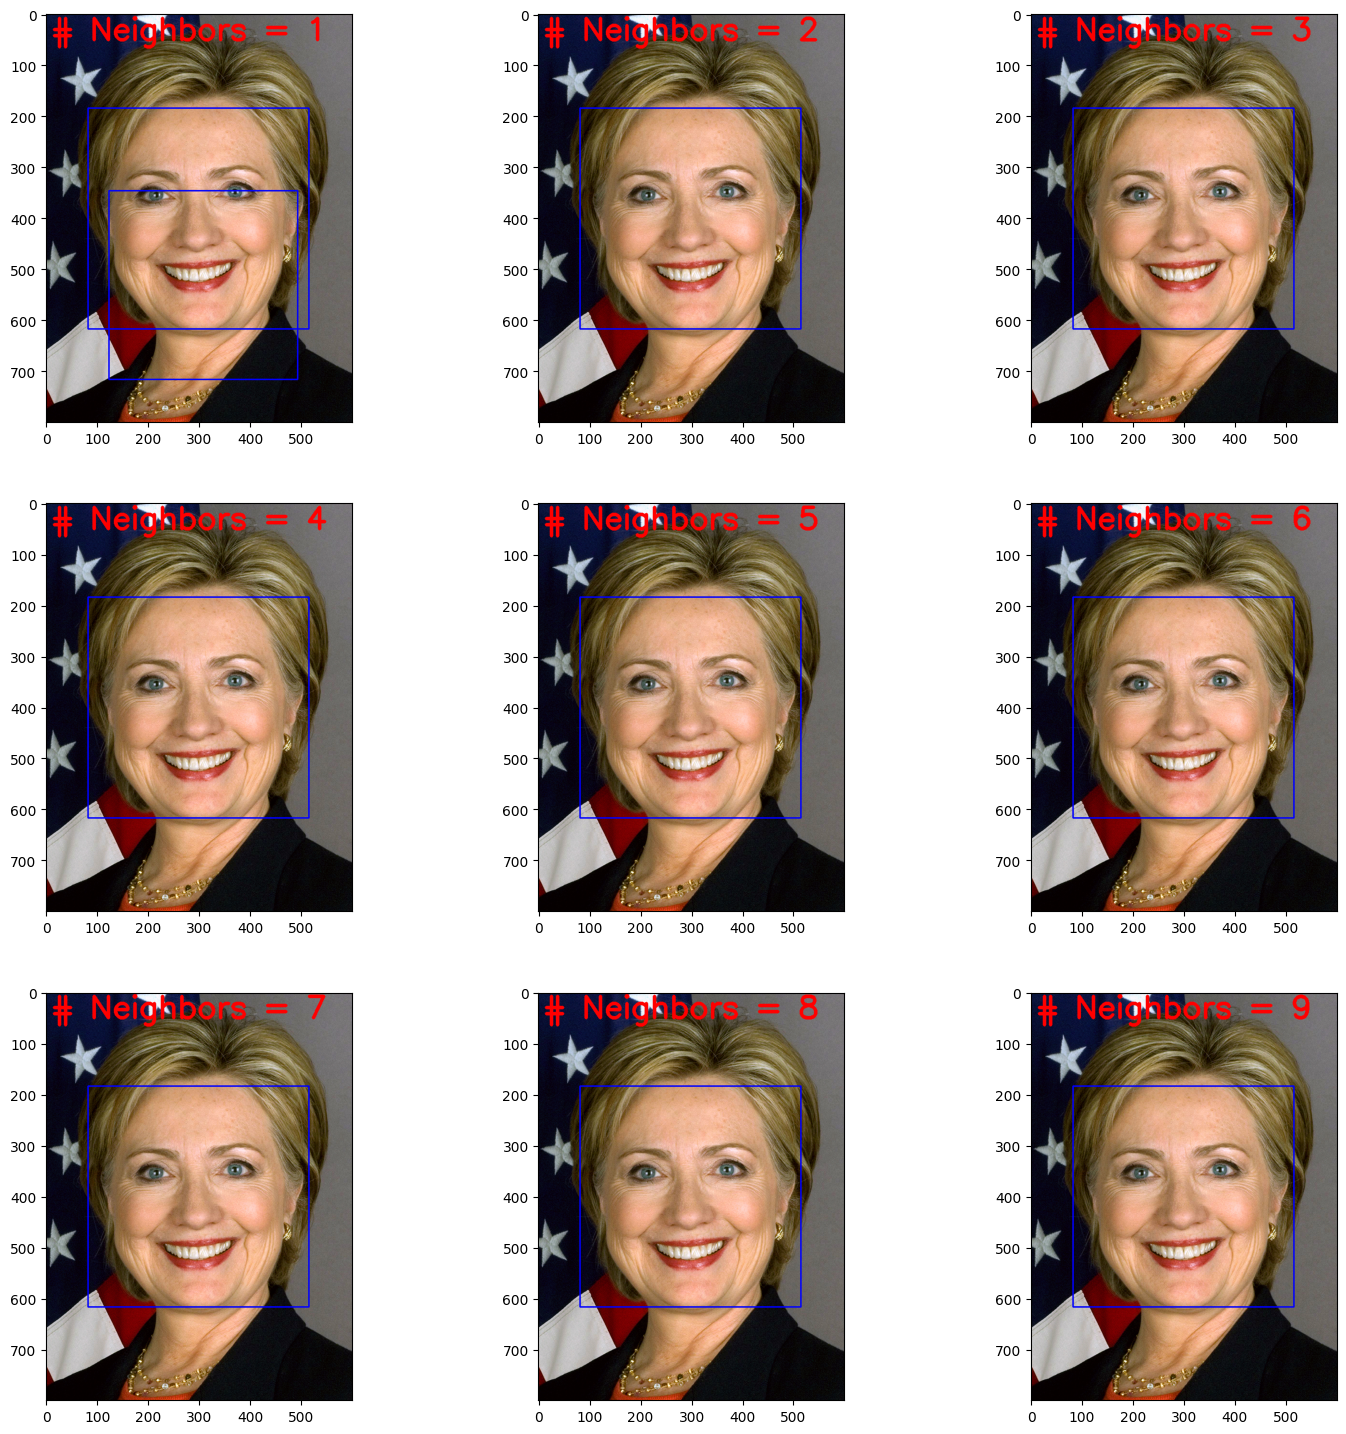

In [4]:
plt.figure(figsize=(18, 18))
count = 1
for neigh in range(1, faceNeighborsMax, neighborStep):
    faces = face_cascade.detectMultiScale(frameGray, 1.2, neigh)
    frameClone = np.copy(frame)

    for (x,y,w,h) in faces:
        cv2.rectangle(frameClone, (x,y), (x+w, y+h), (255,0,0), 2)
    
    cv2.putText(frameClone, "# Neighbors = {}".format(neigh), (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,255), 6)

    plt.subplot(3,3,count)
    plt.imshow(frameClone[:,:,::-1])
    count += 1

plt.show()

In [5]:
face_cascade = cv2.CascadeClassifier('data/models/haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier('data/models/haarcascade_smile.xml')

smileNeighborsMax = 90
neighborStep = 10

frame = cv2.imread('data/images/hillary_clinton.jpg')
frameGray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(frameGray, 1.4, 5)

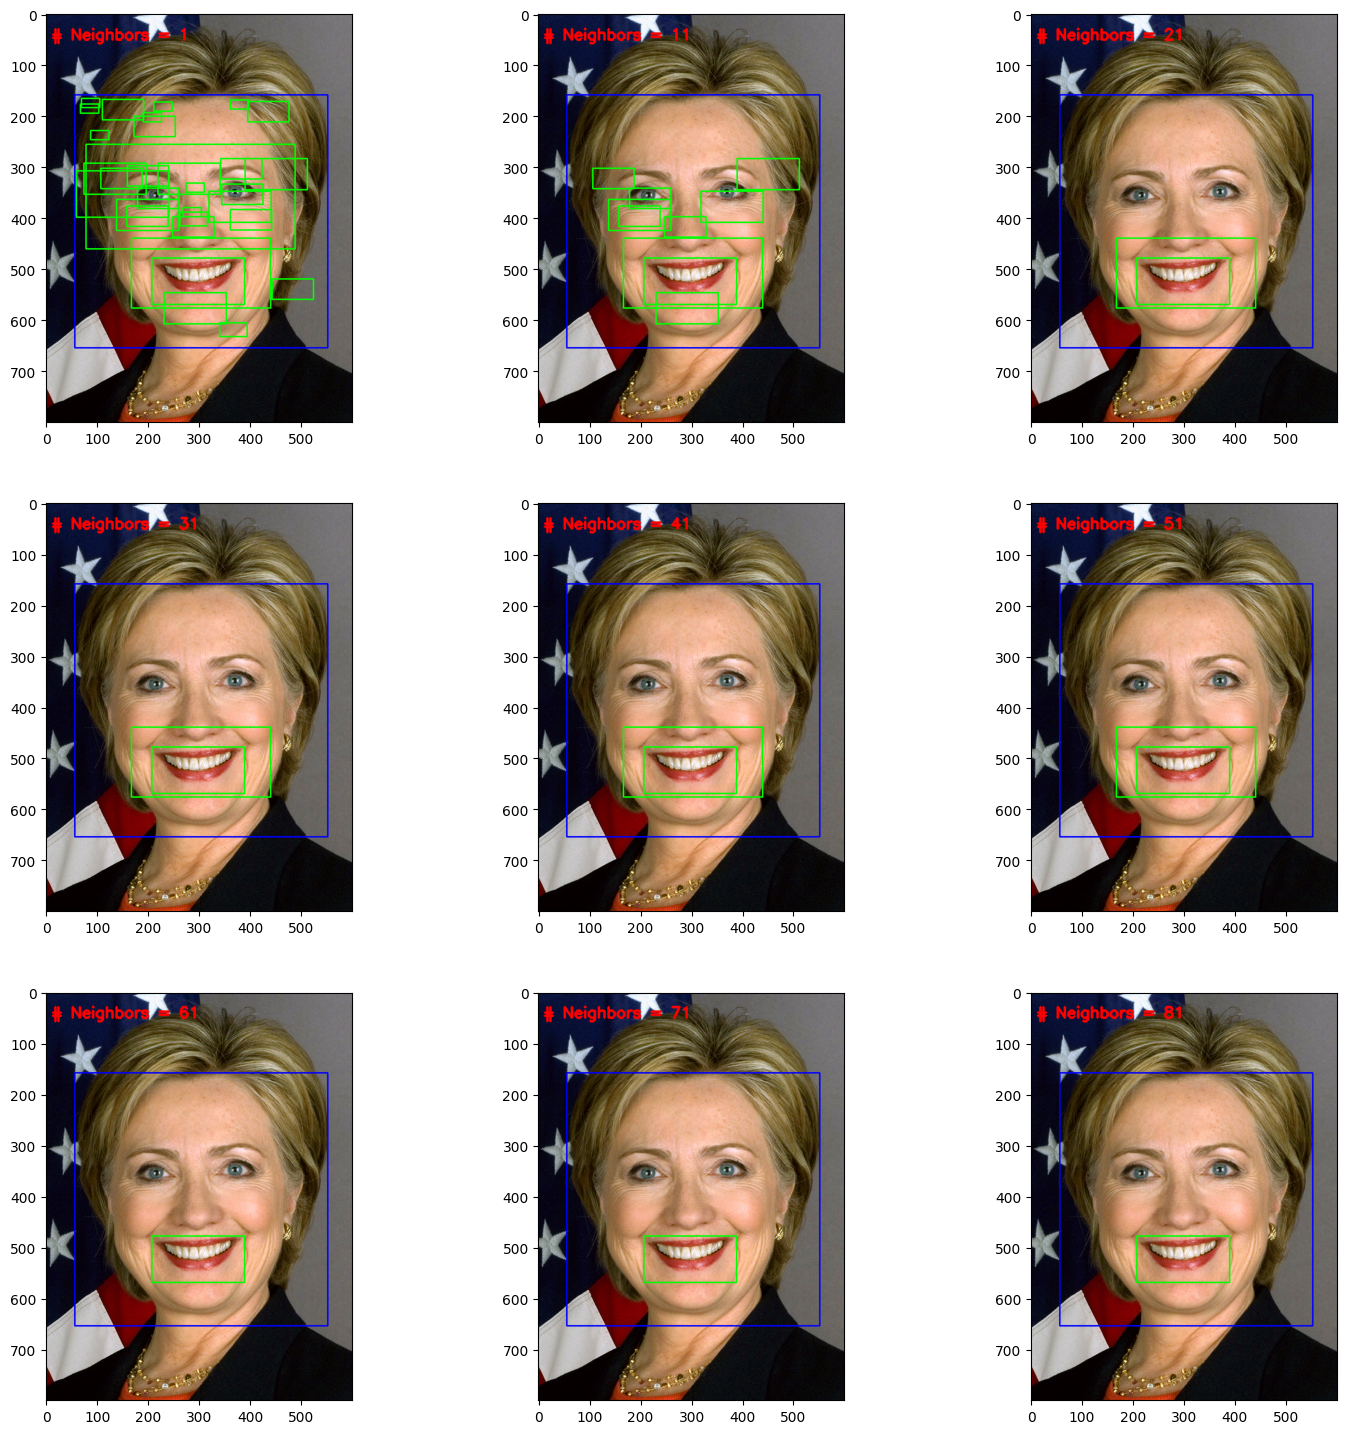

In [6]:
for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x+w, y+h), (255,0,0),2)
    faceRoiGray = frameGray[y: y+h, x: x+w]
    faceRoiOriginal = frame[y: y+h, x: x+w]

count = 1
plt.figure(figsize=(18, 18))

for neigh in range(1, smileNeighborsMax, neighborStep):
    smile = smile_cascade.detectMultiScale(faceRoiGray, 1.5, neigh)
    frameClone = np.copy(frame)
    faceRoiClone = frameClone[y: y+h, x: x+w]

    for(xx, yy, ww, hh) in smile:
        cv2.rectangle(faceRoiClone, (xx, yy), (xx+ww, yy+hh), (0, 255, 0), 2)

    cv2.putText(frameClone, f'# Neighbors = {neigh}', (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 4)

    plt.subplot(3,3,count)
    plt.imshow(frameClone[:,:,::-1])
    count += 1

plt.show()